# 🔴 NOTEBOOK 04 — ResNet50 Transfer Learning
## Objectifs
1. Utiliser ResNet50 pré-entraîné sur ImageNet comme **extracteur de features**
2. **Phase 1 — Feature Extraction** : base gelée → on entraîne uniquement la tête
3. **Phase 2 — Fine-tuning** : dégel des dernières couches pour spécialiser
4. Sauvegarder modèle, courbes, matrice de confusion et features

> **Concept Transfer Learning :**  
> ResNet50 a été entraîné sur 1.2M images (ImageNet). Il a déjà appris à détecter  
> des contours, textures, formes, objets. On réutilise ce savoir pour Flipkart.

> **Prérequis :** avoir exécuté `02_preprocessing.ipynb`

## 1. Imports & chargement de la config

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import os, pickle, json, warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

PROC_DIR    = "../data/processed/"
OUT_MODELS  = "../outputs/models/"
OUT_PLOTS   = "../outputs/plots/"
OUT_RESULTS = "../outputs/results/"

# Charger la config partagée (IMG_SIZE défini en notebook 02)
with open(PROC_DIR + "config.pkl", "rb") as f:
    cfg = pickle.load(f)

IMG_SIZE    = cfg["IMG_SIZE"]
N_CLASSES   = cfg["N_CLASSES"]
INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)

print(f"✅ Config : IMG_SIZE={IMG_SIZE} | N_CLASSES={N_CLASSES} | INPUT_SHAPE={INPUT_SHAPE}")


✅ Config : IMG_SIZE=(96, 96) | N_CLASSES=7 | INPUT_SHAPE=(96, 96, 3)


## 2. Chargement des données

In [2]:
X_train = np.load(PROC_DIR + "X_train.npy")
X_val   = np.load(PROC_DIR + "X_val.npy")
X_test  = np.load(PROC_DIR + "X_test.npy")
y_train = np.load(PROC_DIR + "y_train.npy")
y_val   = np.load(PROC_DIR + "y_val.npy")
y_test  = np.load(PROC_DIR + "y_test.npy")
CLASS_NAMES = np.load(PROC_DIR + "class_names.npy", allow_pickle=True)

# Vérification shape — évite l'erreur du notebook précédent
assert X_train.shape[1:] == INPUT_SHAPE, \
    f"Shape mismatch : {X_train.shape[1:]} ≠ {INPUT_SHAPE}"
print(f"✅ Données OK : X_train={X_train.shape} | X_test={X_test.shape}")


✅ Données OK : X_train=(682, 96, 96, 3) | X_test=(210, 96, 96, 3)


## 3. Construction du modèle ResNet50

**Architecture :**
```
Input (96×96×3)  →  rescale [0,1]→[0,255]  →  preprocess_input ResNet50
  ↓
ResNet50 (poids ImageNet)
  [Phase 1 : GELÉ]  [Phase 2 : 20 dernières couches dégelées]
  ↓
GlobalAveragePooling2D  ← vecteur de features (2048-dim)
  ↓
Dense(512, relu) → BatchNorm → Dropout(0.5)
  ↓
Dense(N_classes, softmax)
```

In [3]:
def build_resnet50(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape, name="input_image")
    
    # ResNet50 attend des pixels [0,255] normalisés par preprocess_input
    # Nos images sont en [0,1] → on rescale d'abord
    x = layers.Rescaling(255.0)(inputs)
    x = tf.keras.applications.resnet50.preprocess_input(x)
    
    # Base pré-entraînée — GELÉE pour Phase 1
    base = ResNet50(include_top=False, weights="imagenet",
                    input_tensor=x, pooling=None)
    base.trainable = False   # ← Phase 1 : tout gelé
    
    # Extraction de features
    features = layers.GlobalAveragePooling2D(name="feature_vector")(base.output)
    
    # Tête de classification
    x = layers.Dense(512, activation="relu")(features)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="predictions")(x)
    
    model = keras.Model(inputs, outputs, name="ResNet50_TL")
    return model, base

model, base_model = build_resnet50(INPUT_SHAPE, N_CLASSES)

trainable  = sum(np.prod(w.shape) for w in model.trainable_weights)
total      = model.count_params()
print(f"Params totaux    : {total:,}")
print(f"Params gelés     : {total - trainable:,}")
print(f"Params entraîn.  : {trainable:,}  (tête uniquement)")


Params totaux    : 24,642,439
Params gelés     : 23,588,736
Params entraîn.  : 1,053,703  (tête uniquement)


## 4. Phase 1 — Feature Extraction (base gelée)

In [4]:
BATCH = 32

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("📌 Phase 1 : Feature Extraction — base ResNet50 gelée")
history_fe = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=BATCH,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=6,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ],
    verbose=1
)
print(f"\nPhase 1 → Best val_accuracy : {max(history_fe.history['val_accuracy'])*100:.2f}%")


📌 Phase 1 : Feature Extraction — base ResNet50 gelée
Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6188 - loss: 1.4334 - val_accuracy: 0.7911 - val_loss: 1.2486 - learning_rate: 0.0010
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 863ms/step - accuracy: 0.9208 - loss: 0.2683 - val_accuracy: 0.7785 - val_loss: 1.1029 - learning_rate: 0.0010
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 858ms/step - accuracy: 0.9721 - loss: 0.1219 - val_accuracy: 0.7785 - val_loss: 1.0250 - learning_rate: 0.0010
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 863ms/step - accuracy: 0.9868 - loss: 0.0638 - val_accuracy: 0.7975 - val_loss: 0.9709 - learning_rate: 0.0010
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 863ms/step - accuracy: 0.9912 - loss: 0.0409 - val_accuracy: 0.8038 - val_loss: 0.9289 - learning_rate: 0.0010
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 869ms/step - accuracy: 0.9927 - loss: 0.0307 - val_accuracy: 0.8038 - val_loss: 0.8610 - learning_rate: 0.0010
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━

## 5. Phase 2 — Fine-tuning (dégel partiel)

In [8]:
N_UNFREEZE = 70  # nombre de couches dégelées depuis la fin

base_model.trainable = True
for layer in base_model.layers[:-N_UNFREEZE]:
    layer.trainable = False

n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Couches dégelées : {n_trainable} / {len(base_model.layers)}")

# LR très faible pour ne pas écraser les poids ImageNet
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n📌 Phase 2 : Fine-tuning")
history_ft = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=BATCH,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=6,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(
            OUT_MODELS + "resnet50.keras",
            monitor="val_accuracy", save_best_only=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ],
    verbose=1
)
print(f"\nPhase 2 → Best val_accuracy : {max(history_ft.history['val_accuracy'])*100:.2f}%")


Couches dégelées : 20 / 176

📌 Phase 2 : Fine-tuning
Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0073
Epoch 1: val_accuracy improved from None to 0.82911, saving model to ../outputs/models/resnet50.keras

Epoch 1: finished saving model to ../outputs/models/resnet50.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 0.8291 - val_loss: 0.8944 - learning_rate: 1.0000e-05
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0071
Epoch 2: val_accuracy did not improve from 0.82911
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 0.8228 - val_loss: 0.8965 - learning_rate: 1.0000e-05
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0060
Epoch 3: val_accuracy did not improve from 0.82911
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.8291 - val_loss: 0.9042 - learning_rate: 1.0000e-

## 6. Courbes combinées FE + Fine-tuning

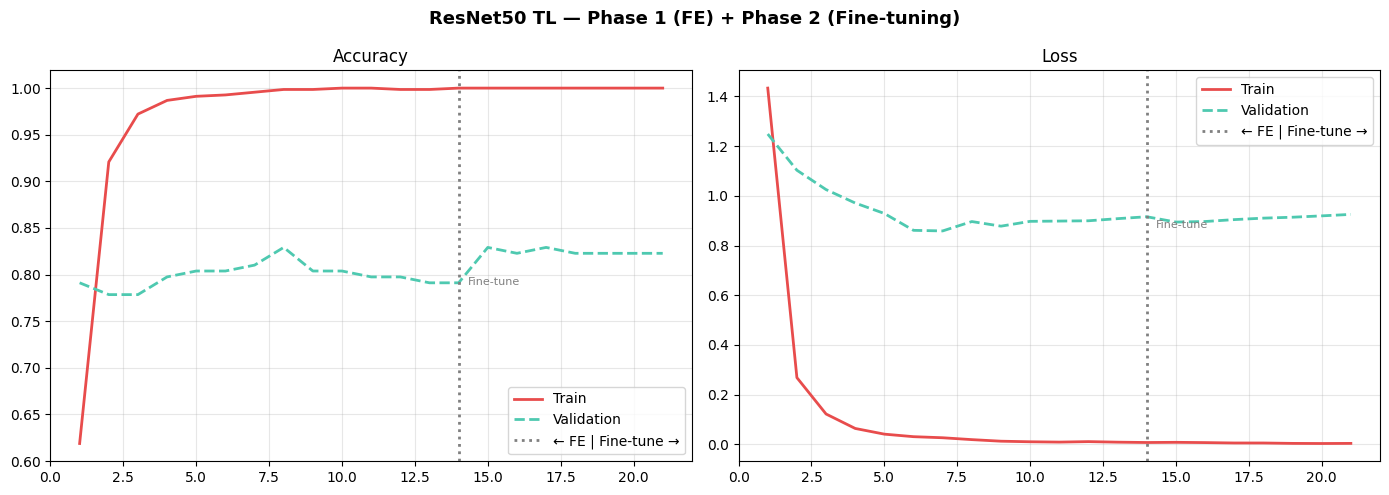

In [9]:
acc  = history_fe.history["accuracy"]     + history_ft.history["accuracy"]
vacc = history_fe.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss = history_fe.history["loss"]         + history_ft.history["loss"]
vloss= history_fe.history["val_loss"]     + history_ft.history["val_loss"]
ep1  = len(history_fe.history["accuracy"])  # frontière Phase1/Phase2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet50 TL — Phase 1 (FE) + Phase 2 (Fine-tuning)", fontsize=13, fontweight="bold")

for ax, tr, vl, title in zip(axes, [acc,loss], [vacc,vloss], ["Accuracy","Loss"]):
    ep = range(1, len(tr)+1)
    ax.plot(ep, tr, label="Train",      color="#E84C4C", lw=2)
    ax.plot(ep, vl, label="Validation", color="#4EC9B0", lw=2, ls="--")
    ax.axvline(ep1, color="gray", ls=":", lw=2, label=f"← FE | Fine-tune →")
    ax.text(ep1+0.3, min(vl)+0.01, "Fine-tune", color="gray", fontsize=8)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PLOTS + "04_curves_resnet50.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Évaluation

Test Accuracy : 76.67%

                            precision    recall  f1-score   support

                 Baby Care       0.82      0.60      0.69        30
  Beauty and Personal Care       0.88      0.77      0.82        30
                 Computers       0.70      0.70      0.70        30
Home Decor & Festive Needs       0.61      0.77      0.68        30
           Home Furnishing       0.72      0.77      0.74        30
          Kitchen & Dining       0.85      0.97      0.91        30
                   Watches       0.86      0.80      0.83        30

                  accuracy                           0.77       210
                 macro avg       0.78      0.77      0.77       210
              weighted avg       0.78      0.77      0.77       210



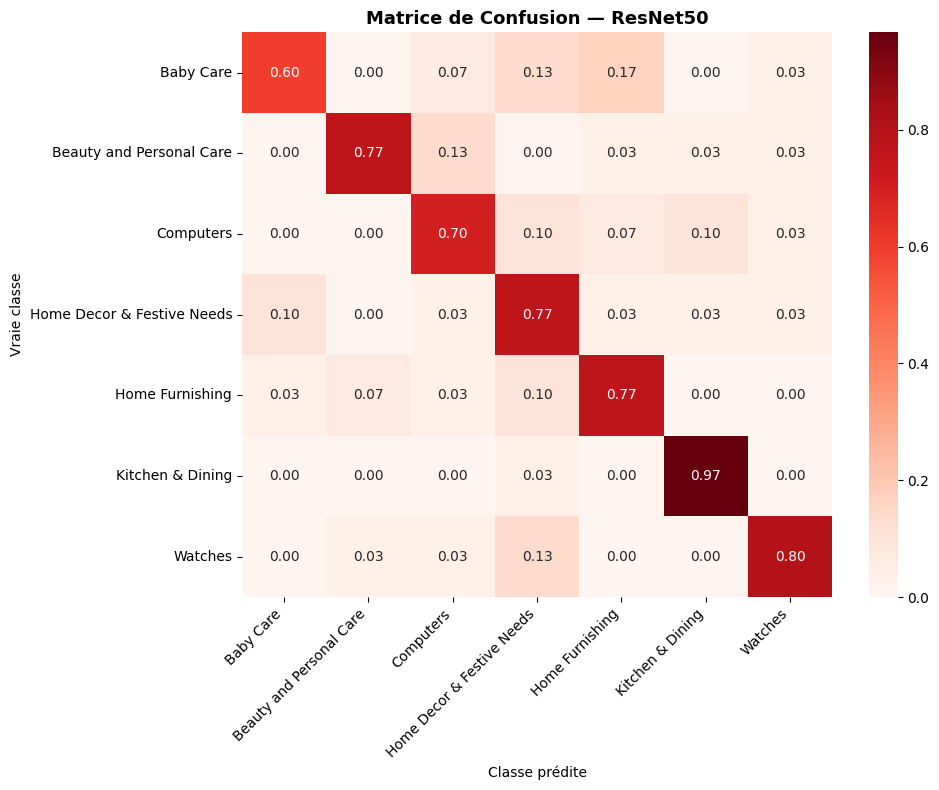

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_pct, annot=True, fmt=".2f", cmap="Reds",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Matrice de Confusion — ResNet50", fontsize=13, fontweight="bold")
ax.set_ylabel("Vraie classe"); ax.set_xlabel("Classe prédite")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(OUT_PLOTS + "04_cm_resnet50.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Extraction de features ResNet50

In [11]:
feature_extractor = keras.Model(
    inputs  = model.input,
    outputs = model.get_layer("feature_vector").output,
    name    = "resnet50_fe"
)

features_train = feature_extractor.predict(X_train, batch_size=32, verbose=1)
features_val   = feature_extractor.predict(X_val,   batch_size=32, verbose=0)
features_test  = feature_extractor.predict(X_test,  batch_size=32, verbose=0)

print(f"Features ResNet50 : {features_train.shape[1]}-dim par image")

np.save(PROC_DIR + "features_train_resnet.npy", features_train)
np.save(PROC_DIR + "features_val_resnet.npy",   features_val)
np.save(PROC_DIR + "features_test_resnet.npy",  features_test)
print("💾 Features sauvegardées")


22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step 
Features ResNet50 : 2048-dim par image
💾 Features sauvegardées


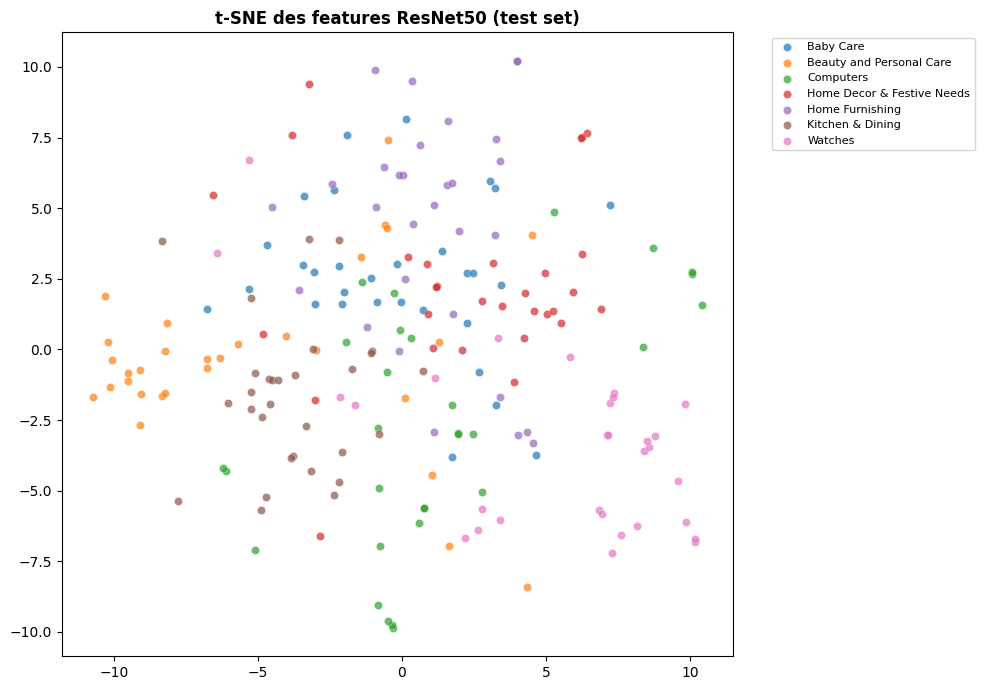

In [13]:
# t-SNE sur les features ResNet50
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
emb  = tsne.fit_transform(features_test)

fig, ax = plt.subplots(figsize=(10, 7))
palette = plt.cm.tab10.colors
for i in range(N_CLASSES):
    mask = (y_test == i)
    ax.scatter(emb[mask,0], emb[mask,1], label=CLASS_NAMES[i],
               color=palette[i], alpha=0.7, s=35,
               edgecolors="white", linewidths=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
ax.set_title("t-SNE des features ResNet50 (test set)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_PLOTS + "04_tsne_resnet50.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Sauvegarde des résultats

In [14]:
results_rn = {
    "model":    "ResNet50 (TL)",
    "accuracy": round(float(test_acc), 4),
    "f1_score": round(float(f1_score(y_test, y_pred, average="weighted")), 4),
    "history":  {
        "accuracy":     [float(v) for v in acc],
        "val_accuracy": [float(v) for v in vacc],
        "loss":         [float(v) for v in loss],
        "val_loss":     [float(v) for v in vloss],
    }
}
with open(OUT_RESULTS + "results_resnet50.json", "w") as f:
    json.dump(results_rn, f, indent=2)

print("="*55)
print("  ✅ NOTEBOOK 04 TERMINÉ — ResNet50")
print("="*55)
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  F1-Score      : {results_rn['f1_score']*100:.2f}%")
print("\n→ Exécuter ensuite : 05_efficientnet.ipynb")


  ✅ NOTEBOOK 04 TERMINÉ — ResNet50
  Test Accuracy : 76.67%
  F1-Score      : 76.66%

→ Exécuter ensuite : 05_efficientnet.ipynb
